In [1]:
import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

COMMENTS_PATH = "/kaggle/input/datasets/advaypatil/youtube-statistics/comments.csv"
VIDEOS_PATH = "/kaggle/input/datasets/advaypatil/youtube-statistics/videos-stats.csv"

OUTPUT_DIR = "/kaggle/working/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Comments path exists:", os.path.exists(COMMENTS_PATH))
print("Videos path exists:", os.path.exists(VIDEOS_PATH))
print("Output directory:", OUTPUT_DIR)

Comments path exists: True
Videos path exists: True
Output directory: /kaggle/working/output


In [2]:
comments_df = pd.read_csv(COMMENTS_PATH)
videos_df = pd.read_csv(VIDEOS_PATH)

print("comments.csv shape:", comments_df.shape)
print("videos-stats.csv shape:", videos_df.shape)

print("\ncomments.csv columns:")
print(comments_df.columns.tolist())

print("\nvideos-stats.csv columns:")
print(videos_df.columns.tolist())

comments_df.head()

comments.csv shape: (18409, 5)
videos-stats.csv shape: (1881, 8)

comments.csv columns:
['Unnamed: 0', 'Video ID', 'Comment', 'Likes', 'Sentiment']

videos-stats.csv columns:
['Unnamed: 0', 'Title', 'Video ID', 'Published At', 'Keyword', 'Likes', 'Comments', 'Views']


,Unnamed: 0,Video ID,Comment,Likes,Sentiment
0,0,wAZZ-UWGVHI,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,1,wAZZ-UWGVHI,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,2,wAZZ-UWGVHI,I will forever acknowledge this channel with t...,161.0,2.0
3,3,wAZZ-UWGVHI,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,4,wAZZ-UWGVHI,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0


In [3]:
df = comments_df[["Comment", "Sentiment"]].copy()

df = df.dropna(subset=["Comment", "Sentiment"])

print("Shape after keeping Comment and Sentiment:", df.shape)
df.head()

Shape after keeping Comment and Sentiment: (18408, 2)


,Comment,Sentiment
0,Let's not forget that Apple Pay in 2014 requir...,1.0
1,Here in NZ 50% of retailers don’t even have co...,0.0
2,I will forever acknowledge this channel with t...,2.0
3,Whenever I go to a place that doesn’t take App...,0.0
4,"Apple Pay is so convenient, secure, and easy t...",2.0


In [4]:
df["Sentiment"] = pd.to_numeric(df["Sentiment"], errors="coerce")

sentiment_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["sentiment_group"] = df["Sentiment"].map(sentiment_map)

df = df.dropna(subset=["sentiment_group"]).copy()

print("Sentiment group counts:")
print(df["sentiment_group"].value_counts())

df.head()

Sentiment group counts:
sentiment_group
positive    11432
neutral      4638
negative     2338
Name: count, dtype: int64


,Comment,Sentiment,sentiment_group
0,Let's not forget that Apple Pay in 2014 requir...,1.0,neutral
1,Here in NZ 50% of retailers don’t even have co...,0.0,negative
2,I will forever acknowledge this channel with t...,2.0,positive
3,Whenever I go to a place that doesn’t take App...,0.0,negative
4,"Apple Pay is so convenient, secure, and easy t...",2.0,positive


Saved: /kaggle/working/output/sentiment_group_counts.csv


,sentiment_group,count
0,positive,11432
1,neutral,4638
2,negative,2338


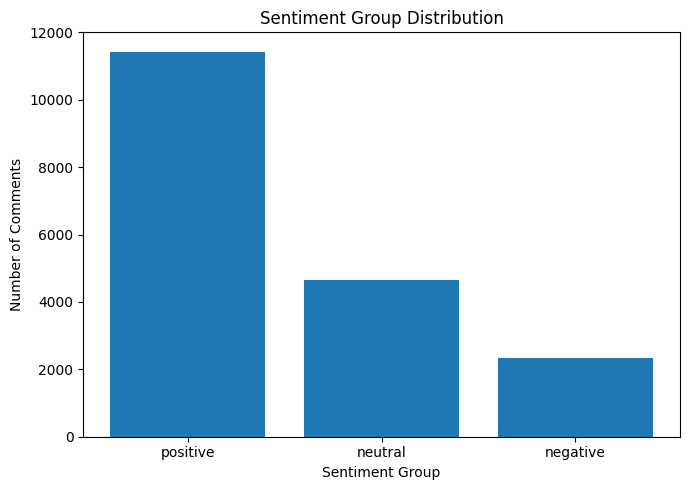

Saved: /kaggle/working/output/sentiment_group_distribution.png


In [5]:
sentiment_counts = df["sentiment_group"].value_counts().reset_index()
sentiment_counts.columns = ["sentiment_group", "count"]

sentiment_counts_path = os.path.join(OUTPUT_DIR, "sentiment_group_counts.csv")
sentiment_counts.to_csv(sentiment_counts_path, index=False)

print("Saved:", sentiment_counts_path)
display(sentiment_counts)

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts["sentiment_group"], sentiment_counts["count"])
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Comments")
plt.title("Sentiment Group Distribution")
plt.tight_layout()

chart_path = os.path.join(OUTPUT_DIR, "sentiment_group_distribution.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

In [6]:
stopwords = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    text = re.sub(r"[^a-z\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [word for word in words if word not in stopwords and len(word) > 2]
    
    return " ".join(words)

df["cleaned_text"] = df["Comment"].apply(clean_text)

df = df[df["cleaned_text"].str.len() > 0].copy()

print("Shape after cleaning:", df.shape)
df[["Comment", "cleaned_text", "sentiment_group"]].head()

Shape after cleaning: (18118, 4)


,Comment,cleaned_text,sentiment_group
0,Let's not forget that Apple Pay in 2014 requir...,let forget apple pay required brand new iphone...,neutral
1,Here in NZ 50% of retailers don’t even have co...,retailers don contactless credit card machines...,negative
2,I will forever acknowledge this channel with t...,forever acknowledge channel help lessons ideas...,positive
3,Whenever I go to a place that doesn’t take App...,place doesn apple pay doesn happen drag contac...,negative
4,"Apple Pay is so convenient, secure, and easy t...",apple pay convenient secure easy use used kore...,positive


In [7]:
cleaned_comments_path = os.path.join(OUTPUT_DIR, "cleaned_comments.csv")
df.to_csv(cleaned_comments_path, index=False)

print("Saved:", cleaned_comments_path)

Saved: /kaggle/working/output/cleaned_comments.csv


In [8]:
def get_top_tfidf_terms(texts, top_n=20, ngram_range=(1, 1)):
    texts = texts.dropna()
    texts = texts[texts.str.len() > 0]
    
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "tfidf_score"])
    
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=ngram_range,
        stop_words="english"
    )
    
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    top_indices = scores.argsort()[::-1][:top_n]
    
    return pd.DataFrame({
        "term": feature_names[top_indices],
        "tfidf_score": scores[top_indices]
    })

In [9]:
tfidf_results = {}

for group in ["positive", "neutral", "negative"]:
    group_texts = df.loc[df["sentiment_group"] == group, "cleaned_text"]
    
    print("=" * 60)
    print(f"{group.upper()} comments:", len(group_texts))
    
    result = get_top_tfidf_terms(
        texts=group_texts,
        top_n=20,
        ngram_range=(1, 1)
    )
    
    tfidf_results[group] = result
    
    file_path = os.path.join(OUTPUT_DIR, f"tfidf_keywords_{group}.csv")
    result.to_csv(file_path, index=False)
    
    print("Saved:", file_path)
    display(result)

POSITIVE comments: 11375
Saved: /kaggle/working/output/tfidf_keywords_positive.csv


,term,tfidf_score
0,love,0.031640
1,thank,0.021591
2,video,0.021006
3,great,0.020589
4,just,0.019311
5,like,0.019124
6,good,0.018328
7,really,0.016678
8,videos,0.016026
9,thanks,0.013852


NEUTRAL comments: 4408
Saved: /kaggle/working/output/tfidf_keywords_neutral.csv


,term,tfidf_score
0,like,0.017414
1,que,0.013917
2,just,0.013616
3,video,0.012667
4,time,0.009995
5,know,0.009136
6,don,0.008898
7,make,0.008323
8,people,0.007694
9,think,0.007476


NEGATIVE comments: 2335
Saved: /kaggle/working/output/tfidf_keywords_negative.csv


,term,tfidf_score
0,like,0.020467
1,just,0.020186
2,people,0.019417
3,don,0.017345
4,know,0.012560
5,time,0.012515
6,really,0.010379
7,think,0.009739
8,make,0.009134
9,got,0.009130


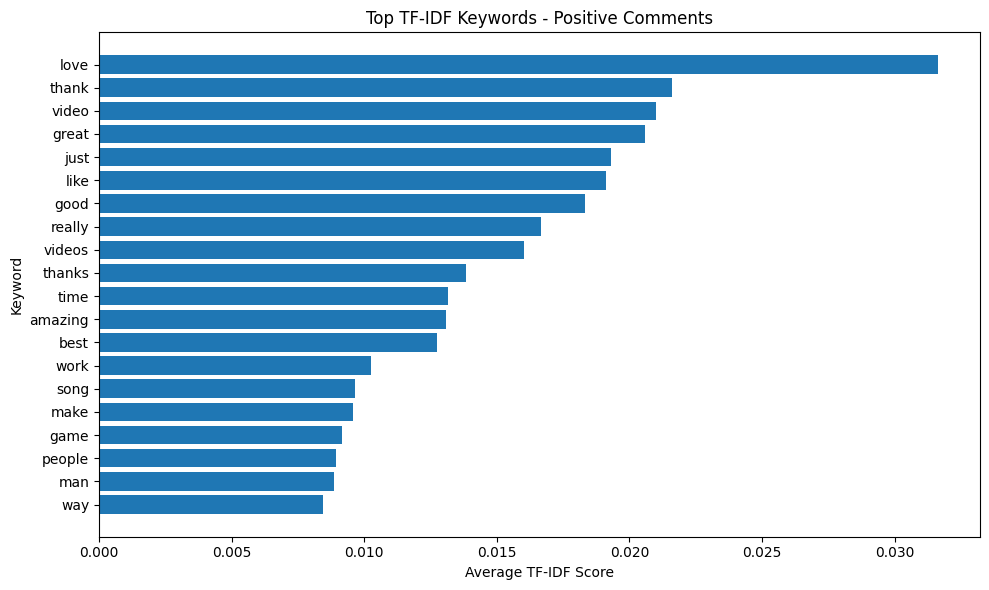

Saved: /kaggle/working/output/tfidf_keywords_positive.png


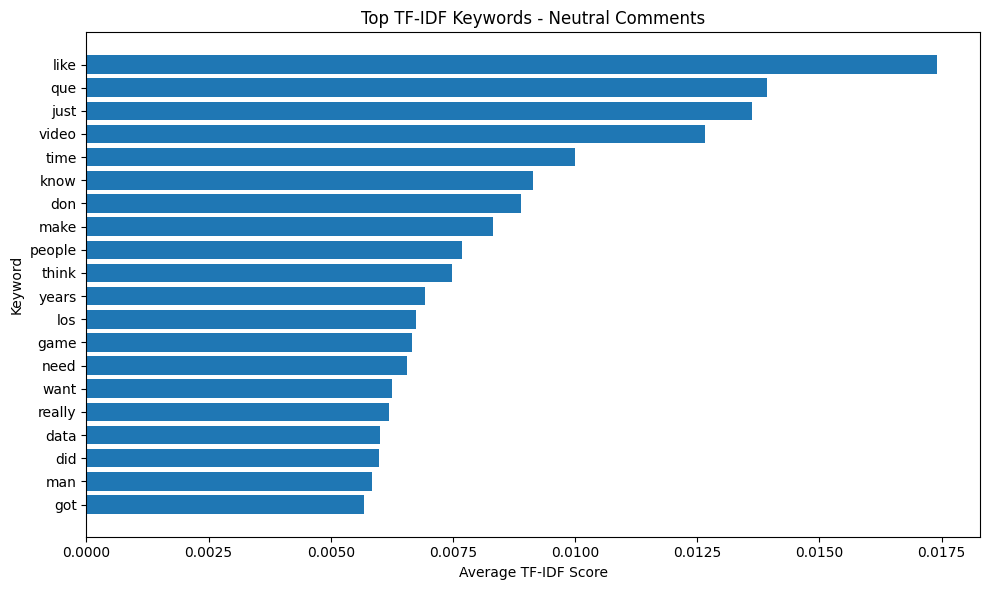

Saved: /kaggle/working/output/tfidf_keywords_neutral.png


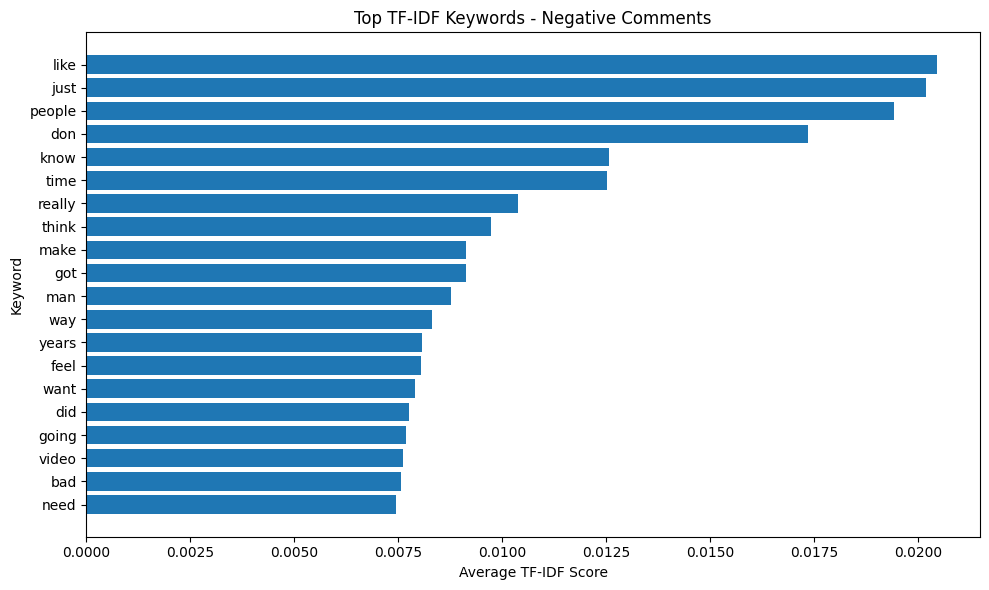

Saved: /kaggle/working/output/tfidf_keywords_negative.png


In [10]:
for group, result in tfidf_results.items():
    if result.empty:
        print(f"No TF-IDF keyword result for {group}")
        continue
    
    plt.figure(figsize=(10, 6))
    plt.barh(result["term"][::-1], result["tfidf_score"][::-1])
    plt.xlabel("Average TF-IDF Score")
    plt.ylabel("Keyword")
    plt.title(f"Top TF-IDF Keywords - {group.capitalize()} Comments")
    plt.tight_layout()
    
    chart_path = os.path.join(OUTPUT_DIR, f"tfidf_keywords_{group}.png")
    plt.savefig(chart_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", chart_path)

In [11]:
bigram_results = {}

for group in ["positive", "neutral", "negative"]:
    group_texts = df.loc[df["sentiment_group"] == group, "cleaned_text"]
    
    print("=" * 60)
    print(f"{group.upper()} comments:", len(group_texts))
    
    result = get_top_tfidf_terms(
        texts=group_texts,
        top_n=20,
        ngram_range=(2, 2)
    )
    
    bigram_results[group] = result
    
    file_path = os.path.join(OUTPUT_DIR, f"bigrams_{group}.csv")
    result.to_csv(file_path, index=False)
    
    print("Saved:", file_path)
    display(result)

POSITIVE comments: 11375
Saved: /kaggle/working/output/bigrams_positive.csv


,term,tfidf_score
0,great video,0.005391
1,data science,0.004516
2,good work,0.004172
3,feel like,0.004118
4,love videos,0.003917
5,really good,0.003905
6,machine learning,0.003561
7,looking forward,0.003363
8,great job,0.003362
9,computer science,0.002828


NEUTRAL comments: 4408
Saved: /kaggle/working/output/bigrams_neutral.csv


,term,tfidf_score
0,data science,0.003809
1,don know,0.003729
2,los mejores,0.003697
3,mejores conciertos,0.003607
4,feel like,0.003532
5,machine learning,0.003412
6,son unos,0.003157
7,unos los,0.003152
8,years ago,0.003088
9,fun fact,0.002750


NEGATIVE comments: 2335
Saved: /kaggle/working/output/bigrams_negative.csv


,term,tfidf_score
0,don know,0.006640
1,feel like,0.004731
2,sounds like,0.004008
3,years ago,0.003325
4,feel bad,0.002745
5,people like,0.002631
6,don think,0.002550
7,don want,0.002494
8,just like,0.002402
9,high school,0.002195


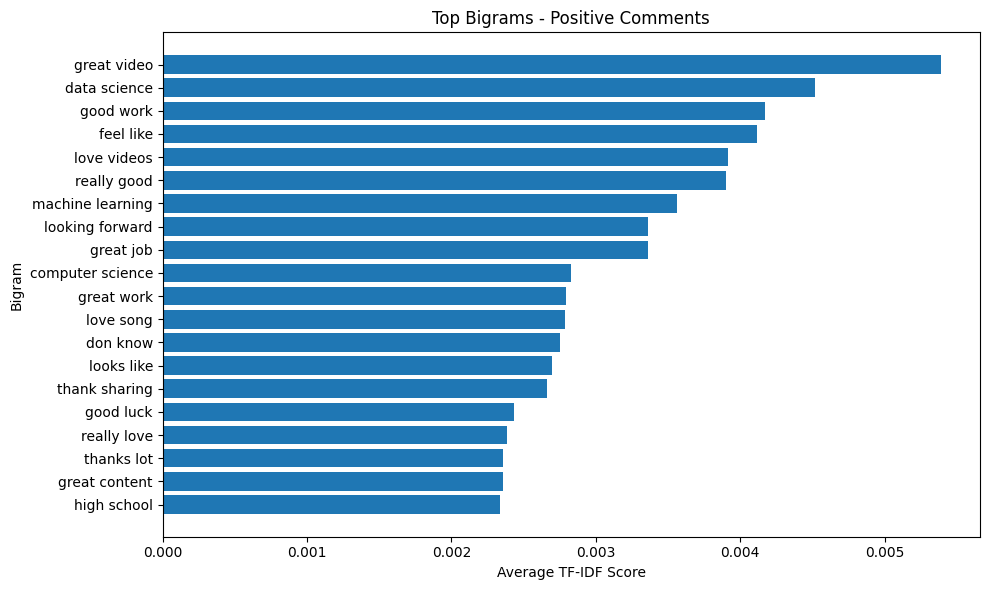

Saved: /kaggle/working/output/bigrams_positive.png


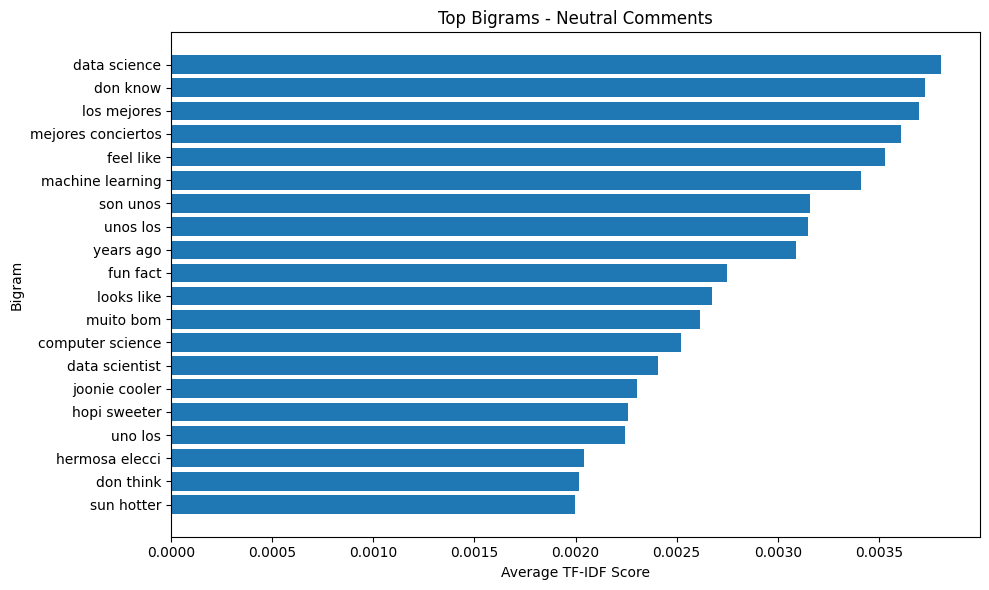

Saved: /kaggle/working/output/bigrams_neutral.png


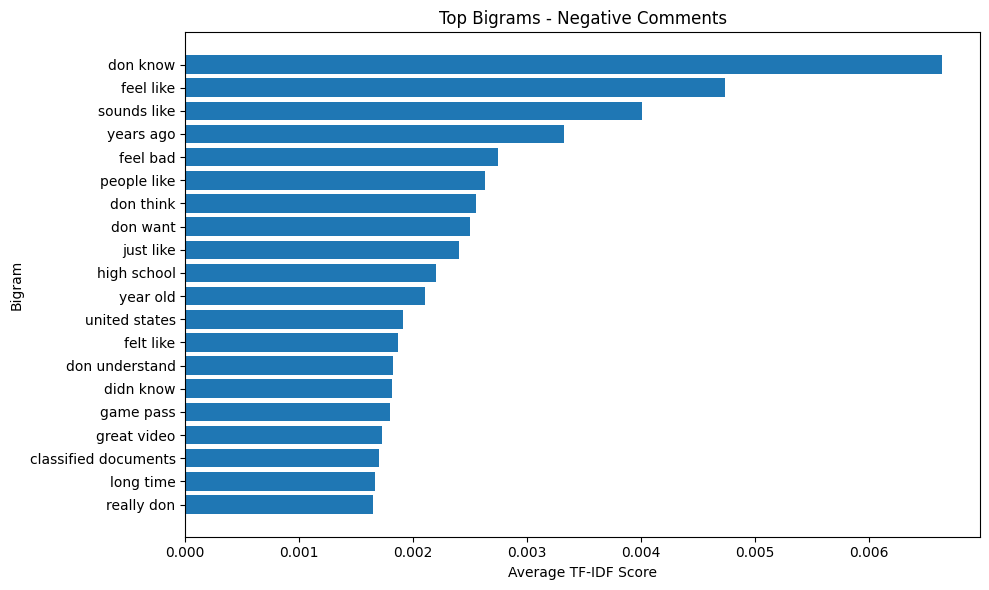

Saved: /kaggle/working/output/bigrams_negative.png


In [12]:
for group, result in bigram_results.items():
    if result.empty:
        print(f"No bigram result for {group}")
        continue
    
    plt.figure(figsize=(10, 6))
    plt.barh(result["term"][::-1], result["tfidf_score"][::-1])
    plt.xlabel("Average TF-IDF Score")
    plt.ylabel("Bigram")
    plt.title(f"Top Bigrams - {group.capitalize()} Comments")
    plt.tight_layout()
    
    chart_path = os.path.join(OUTPUT_DIR, f"bigrams_{group}.png")
    plt.savefig(chart_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", chart_path)

In [13]:
summary_rows = []

for group in ["positive", "neutral", "negative"]:
    top_keywords = ", ".join(tfidf_results[group]["term"].head(5).tolist())
    top_bigrams = ", ".join(bigram_results[group]["term"].head(5).tolist())
    
    summary_rows.append({
        "sentiment_group": group,
        "top_5_tfidf_keywords": top_keywords,
        "top_5_bigrams": top_bigrams,
        "possible_theme_label": "to be manually interpreted"
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(OUTPUT_DIR, "sentiment_theme_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary_df)

Saved: /kaggle/working/output/sentiment_theme_summary.csv


,sentiment_group,top_5_tfidf_keywords,top_5_bigrams,possible_theme_label
0,positive,"love, thank, video, great, just","great video, data science, good work, feel lik...",to be manually interpreted
1,neutral,"like, que, just, video, time","data science, don know, los mejores, mejores c...",to be manually interpreted
2,negative,"like, just, people, don, know","don know, feel like, sounds like, years ago, f...",to be manually interpreted


In [14]:
excel_path = os.path.join(OUTPUT_DIR, "final_analysis_outputs.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    sentiment_counts.to_excel(writer, sheet_name="sentiment_counts", index=False)
    
    for group in ["positive", "neutral", "negative"]:
        tfidf_results[group].to_excel(writer, sheet_name=f"tfidf_{group}", index=False)
        bigram_results[group].to_excel(writer, sheet_name=f"bigrams_{group}", index=False)
    
    summary_df.to_excel(writer, sheet_name="theme_summary", index=False)

print("Saved:", excel_path)

Saved: /kaggle/working/output/final_analysis_outputs.xlsx


In [15]:
print("Files created in output folder:")

for file in os.listdir(OUTPUT_DIR):
    print(file)

Files created in output folder:
tfidf_keywords_positive.png
bigrams_positive.png
final_analysis_outputs.xlsx
bigrams_negative.csv
tfidf_keywords_neutral.csv
bigrams_neutral.png
sentiment_theme_summary.csv
sentiment_group_counts.csv
bigrams_neutral.csv
sentiment_group_distribution.png
tfidf_keywords_neutral.png
cleaned_comments.csv
tfidf_keywords_positive.csv
bigrams_negative.png
tfidf_keywords_negative.csv
bigrams_positive.csv
tfidf_keywords_negative.png


In [16]:
zip_path = "/kaggle/working/output.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUTPUT_DIR)
            zipf.write(full_path, arcname)

print("Created ZIP file:", zip_path)

Created ZIP file: /kaggle/working/output.zip
